# Load all the imports!

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler


import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pylab
import seaborn as sns;
import string

In [2]:
!pip install transformers

In [3]:
!pip install huggingface_hub

In [4]:
!pip install fasttext

In [5]:
!pip install torchmetrics

In [6]:
# RTX 5090 (compute capability 12.0a) is not supported by the installed TensorFlow.
# TF would JIT-compile from PTX which takes 30+ minutes and crashes the kernel.
# All training uses PyTorch, so this TF check is skipped.

# import tensorflow as tf
# device_name = tf.test.gpu_device_name()
# if device_name == '/device:GPU:0':
#     print('Found GPU at: {}'.format(device_name))
# else:
#     raise SystemError('GPU device not found')


In [7]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: NVIDIA GeForce RTX 5090


In [8]:
import glob
import pandas as pd
import csv
import re
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from transformers import AutoTokenizer, AutoModel, AdamW, BertTokenizer, BertForSequenceClassification, GPT2Model,GPT2ForSequenceClassification
import torch

from torch import tensor
from torchmetrics.regression import KendallRankCorrCoef

import fasttext
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler
from transformers import get_linear_schedule_with_warmup
import matplotlib.pyplot as plt

import pandas as pd
import json

import random
import numpy as np
import os

I0000 00:00:1778032511.327428   78924 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778032511.350033   78924 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778032512.063692   78924 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [9]:
# from google.colab import auth
# auth.authenticate_user()

# import gspread
# from google.auth import default
# creds, _ = default()

# gc = gspread.authorize(creds)


In [10]:
import os

data_path = os.path.join(os.path.dirname(os.getcwd()), 'Data',
                         'BEA 2024 Task Data Extended Shuffled - BEA 2024 Task Data Extended Shuffled.csv')
rows = pd.read_csv(data_path).to_dict('records')
print(f"Loaded {len(rows)} records from local file.")


Loaded 466 records from local file.


In [11]:
# Convert to a DataFrame and render.
import pandas as pd

dataset = pd.DataFrame.from_records(rows)
dataset

,ItemNum,ItemStem_Text,Answer__A,Answer__B,Answer__C,Answer__D,Answer__E,Answer__F,Answer__G,Answer__H,...,all_input,q_answers_input,answers_input,q_a_input,step_integer,Falcon_answer,Meditron_answer,Mistral_answer,llms_a_input,q_llms_a_input
0,622,A 27-year-old man comes to the emergency depar...,Choristoma,Ciliary epithelium,Endothelial cells,Gastric mucosa,Striated muscle,NaN,NaN,NaN,...,A 27-year-old man comes to the emergency depar...,A 27-year-old man comes to the emergency depar...,Choristoma. Ciliary epithelium. Endothelial ce...,A 27-year-old man comes to the emergency depar...,0,(A) Ciliary epithelium (B) Endothelial cells (C),EOD> .\nThe authors report a case of a 45-year...,/s>,(A) Ciliary epithelium (B) Endothelial cells (...,A 27-year-old man comes to the emergency depar...
1,440,"A 39-year-old woman, gravida 2, para 2, comes ...",Future fertility plans,Hypertension,Obesity,Patient age,Stage of disease,NaN,NaN,NaN,...,"A 39-year-old woman, gravida 2, para 2, comes ...","A 39-year-old woman, gravida 2, para 2, comes ...",Future fertility plans. Hypertension. Obesity....,"A 39-year-old woman, gravida 2, para 2, comes ...",2,The correct answer is C.\nThe correct answer i...,\n\n\nA. Future fertility plans\n\n\n\nB. Hype...,/s>,The correct answer is C. The correct answer is...,"A 39-year-old woman, gravida 2, para 2, comes ..."
2,12,An 18-year-old primigravid woman comes for her...,Repeat measurement of MSAFP concentration,"Triple screening for MSAFP, serum Î²-hCG, and ...",Ultrasonography,Amniocentesis for measurement of Î±-fetoprotei...,Amniocentesis for chromosomal analysis,NaN,NaN,NaN,...,An 18-year-old primigravid woman comes for her...,An 18-year-old primigravid woman comes for her...,Repeat measurement of MSAFP concentration. Tri...,An 18-year-old primigravid woman comes for her...,1,The correct answer is: C. Ultrasonography.\nTh...,\n## Answer:\nThe correct answer is option C. ...,\nThe correct answer is C. Ultrasonography.\n\...,The correct answer is: C. Ultrasonography. The...,An 18-year-old primigravid woman comes for her...
3,5,"A 26-year-old man, who is admitted to the hosp...",There is no evidence of a familial coagulation...,Half of their daughters will have a clinically...,The sons of their daughters will be at risk fo...,Their sons will be at risk for a clinically ev...,Their sons and daughters will be at risk for a...,NaN,NaN,NaN,...,"A 26-year-old man, who is admitted to the hosp...","A 26-year-old man, who is admitted to the hosp...",There is no evidence of a familial coagulation...,"A 26-year-old man, who is admitted to the hosp...",2,The answer is E.\nThe answer is E.\nThe answer...,\n## Answer:\nThe correct answer is option E. ...,\nThe correct answer is D.\n\nThe patient has ...,The answer is E. The answer is E. The answer i...,"A 26-year-old man, who is admitted to the hosp..."
4,221,A 60-year-old man had a total thyroidectomy an...,Babinski sign present bilaterally,Chvostek sign,Deviation of the tongue to the left side,A drooping left shoulder,Hyporeflexia,NaN,NaN,NaN,...,A 60-year-old man had a total thyroidectomy an...,A 60-year-old man had a total thyroidectomy an...,Babinski sign present bilaterally. Chvostek si...,A 60-year-old man had a total thyroidectomy an...,2,The correct answer is: C. Deviation of the ton...,\n\n\nA. Babinski sign present bilaterally\n\n...,\nThe correct answer is E. Hyporeflexia.\n\nTh...,The correct answer is: C. Deviation of the ton...,A 60-year-old man had a total thyroidectomy an...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,631,A 63-year-old man with chronic obstructive pul...,Continuous nebulized albuterol therapy,CT scan of the chest without contrast,Intravenous aminophylline therapy,Pulmonary function testing,Pulmonary rehabilitation,Titrated oxygen therapy,NaN,NaN,...,A 63-year-old man with chronic obstructive pul...,A 63-year-old man with chronic obstructive pul...,Continuous nebulized albuterol therapy. 

# Dataset preprocessing

In [12]:
def transform_column_difficulty(df_column):
  scaler_difficulty = MinMaxScaler()
  scores = np.array(df_column)
  scores = scores.reshape(-1,1)
  scaler_difficulty.fit(scores)
  scores = scaler_difficulty.transform(scores)
  scores = np.float32(scores)
  return scores, scaler_difficulty

In [13]:
dataset['Answer__A'] = dataset['Answer__A'].apply(str)
dataset['Answer__B'] = dataset['Answer__B'].apply(str)
dataset['Answer__C'] = dataset['Answer__C'].apply(str)
dataset['Answer__D'] = dataset['Answer__D'].apply(str)
dataset['Answer__E'] = dataset['Answer__E'].apply(str)
dataset['Answer__F'] = dataset['Answer__F'].apply(str)
dataset['Answer__G'] = dataset['Answer__G'].apply(str)
dataset['Answer__H'] = dataset['Answer__H'].apply(str)
dataset['Answer__I'] = dataset['Answer__I'].apply(str)
dataset['Answer__J'] = dataset['Answer__J'].apply(str)
dataset['Answer_Key'] = dataset['Answer_Key'].apply(str)
dataset['Answer_Text'] = dataset['Answer_Text'].apply(str)
dataset['all_input'] = dataset['all_input'].apply(str)
dataset['q_answers_input'] = dataset['q_answers_input'].apply(str)
dataset['answers_input'] = dataset['answers_input'].apply(str)
dataset['q_a_input'] = dataset['q_a_input'].apply(str)
dataset['llms_a_input'] = dataset['llms_a_input'].apply(str)
dataset['q_llms_a_input'] = dataset['q_llms_a_input'].apply(str)

In [14]:
dataset['q_answers_llms_a_input'] = dataset['q_answers_input'] + '. ' + dataset['llms_a_input']

In [15]:
(dataset['Difficulty'], scaler_difficulty) = transform_column_difficulty(dataset['Difficulty'])

In [16]:
fold_1 = dataset[:92]
fold_2 = dataset[93:185]
fold_3 = dataset[186:278]
fold_4 = dataset[279:371]
fold_5 = dataset[372:465]

print(len(fold_1))
print(len(fold_2))
print(len(fold_3))
print(len(fold_4))
print(len(fold_5))
# len(fold_1.append(fold_2))

92
92
92
92
93


#Load BERT for classification

In [17]:
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# model = BertForSequenceClassification.from_pretrained('bert-base-uncased')

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = GPT2ForSequenceClassification.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

/home/bojingyy/CSEN 346/BEA-2024/venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
class CustomGPTForSeqClassification(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gpt = GPT2ForSequenceClassification.from_pretrained("gpt2")
        self.gpt.score = torch.nn.Linear(768, 1, bias=True)
        self.gpt.config.pad_token_id = self.gpt.config.eos_token_id
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, ids, mask):
        gpt_out = self.gpt(ids, attention_mask=mask)
        # print("inainte de logits")
        # print(gpt_out.logits)
        # print(gpt_out.shape)
        sigm = self.sigmoid(gpt_out.logits)

        return (sigm)

In [19]:
import time
import datetime

def format_time(elapsed):
    '''
    Takes a time in seconds and returns a string hh:mm:ss
    '''
    # Round to the nearest second.
    elapsed_rounded = int(round((elapsed)))

    # Format as hh:mm:ss
    return str(datetime.timedelta(seconds=elapsed_rounded))


In [20]:
def k_fold_training(df_train, df_validation):
  print('Number of training sentences: {:,}\n'.format(df_train.shape[0]))
  print('Number of validation sentences: {:,}\n'.format(df_validation.shape[0]))

  ### TRAIN ###
  inputs_train = df_train.q_answers_input.values
  labels_train = df_train.Difficulty.values

  ### VALIDATION ###
  inputs_validation = df_validation.q_answers_input.values
  labels_validation = df_validation.Difficulty.values

  tokenizer = AutoTokenizer.from_pretrained("gpt2")
  tokenizer.pad_token = tokenizer.eos_token
  model = CustomGPTForSeqClassification()

  # Tokenize all of the sentences and map the tokens to thier word IDs.
  input_ids_train = []
  attention_masks_train = []
  # token_type_ids_train = []

  # For every webpage content.
  for content in inputs_train:
      encoded_dict = tokenizer.encode_plus(
                          content,                   # Sentence to encode.
                          add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                          max_length = 300,           # Pad & truncate all sentences.
                          pad_to_max_length = True,
                          return_attention_mask = True,   # Construct attn. masks.
                          return_tensors = 'pt',     # Return pytorch tensors.
                    )
      # Add the encoded sentence to the list.
      input_ids_train.append(encoded_dict['input_ids'])

      # And its attention mask (simply differentiates padding from non-padding).
      attention_masks_train.append(encoded_dict['attention_mask'])

      # token_type_ids_train.append(encoded_dict['token_type_ids'])

  # Convert the lists into tensors.
  input_ids_train = torch.cat(input_ids_train, dim=0)
  attention_masks_train = torch.cat(attention_masks_train, dim=0)
  # token_type_ids_train = torch.cat(token_type_ids_train, dim = 0)
  labels_train = torch.tensor(labels_train)

  # # Print sentence 0, now as a list of IDs.
  # print('Original: ', inputs_train[0])
  # print('Token IDs:', input_ids_train[0])


  # Tokenize all of the sentences and map the tokens to thier word IDs.
  input_ids_validation = []
  attention_masks_validation = []
  # token_type_ids_validation = []

  # For every webpage content.
  for content in inputs_validation:
      encoded_dict = tokenizer.encode_plus(
                          content,                   # Sentence to encode.
                          add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                          max_length = 300,           # Pad & truncate all sentences.
                          pad_to_max_length = True,
                          return_attention_mask = True,   # Construct attn. masks.
                          return_tensors = 'pt',     # Return pytorch tensors.
                    )

      # Add the encoded sentence to the list.
      input_ids_validation.append(encoded_dict['input_ids'])

      # And its attention mask (simply differentiates padding from non-padding).
      attention_masks_validation.append(encoded_dict['attention_mask'])

      # token_type_ids_validation.append(encoded_dict['token_type_ids'])

  # Convert the lists into tensors.
  input_ids_validation = torch.cat(input_ids_validation, dim=0)
  attention_masks_validation = torch.cat(attention_masks_validation, dim=0)
  # token_type_ids_validation = torch.cat(token_type_ids_validation, dim=0)
  labels_validation = torch.tensor(labels_validation)

  # Print sentence 0, now as a list of IDs.
  # print('Original: ', inputs_validation[0])
  # print('Token IDs:', input_ids_validation[0])


  # Combine the training inputs into a TensorDataset.
  train_dataset = TensorDataset(input_ids_train, attention_masks_train, labels_train)
  validation_dataset = TensorDataset(input_ids_validation, attention_masks_validation, labels_validation)


  batch_size = 32

  train_dataloader = DataLoader(
              train_dataset,  # The training samples.
              sampler = RandomSampler(train_dataset), # Select batches randomly
              batch_size = batch_size, # Trains with this batch size.
              num_workers=0
          )

  validation_dataloader = DataLoader(
              validation_dataset, # The validation samples.
              sampler = RandomSampler(validation_dataset), # Pull out batches sequentially.
              batch_size = batch_size, num_workers=0 # Evaluate with this batch size.
          )

  # Tell pytorch to run this model on the GPU.
  model.cuda()

  epochs = 10

  # Total number of training steps is [number of batches] x [number of epochs].
  # (Note that this is not the same as the number of training samples).
  total_steps = len(train_dataloader) * epochs

  optimizer = AdamW(model.parameters(),
                    lr = 1e-5, # args.learning_rate - default is 5e-5, our notebook had 2e-5
                    eps = 1e-8 # args.adam_epsilon  - default is 1e-8.
                  )

  # Create the learning rate scheduler.
  scheduler = get_linear_schedule_with_warmup(optimizer,
                                              num_warmup_steps = 0, # Default value in run_glue.py
                                              num_training_steps = total_steps)
  seed_val = 42

  criterion = torch.nn.MSELoss()
  kendall = KendallRankCorrCoef()

  training_stats = []
  total_t0 = time.time()

  print("train")
  # For each epoch...
  for epoch_i in range(0, epochs):

      # ========================================
      #               Training
      # ========================================

      # Perform one full pass over the training set.

      print("")
      print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
      print('Training...')

      # Measure how long the training epoch takes.
      t0 = time.time()

      # Reset the total loss for this epoch.
      total_train_loss = 0
      total_train_kendall_corr = 0
      model.train()

      # For each batch of training data...
      for step, batch in enumerate(train_dataloader):

          # Progress update every 40 batches.
          if step % 500 == 0 and not step == 0:
              # Calculate elapsed time in minutes.
              elapsed = format_time(time.time() - t0)

              # Report progress.
              print('  Batch {:>5,}  of  {:>5,}.    Elapsed: {:}.'.format(step, len(train_dataloader), elapsed))


          # print(batch[0])
          b_input_ids = batch[0].to(device)
          b_input_mask = batch[1].to(device)
          b_labels = batch[2].to(device)

          model.zero_grad()


          # print("aici")

          outputs = model(b_input_ids, b_input_mask)
          outputs = outputs.squeeze(1)
          # print(outputs)
          # print(b_labels)
          loss = criterion(outputs, b_labels)

          total_train_loss += loss.item()

          kendall_corr = kendall(outputs, b_labels)
          # print("Kendall corr: ", kendall_corr)
          total_train_kendall_corr += kendall_corr.item()

          loss.backward()

          # Clip the norm of the gradients to 1.0.
          # This is to help prevent the "exploding gradients" problem.
          torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

          # Update parameters and take a step using the computed gradient.
          # The optimizer dictates the "update rule"--how the parameters are
          # modified based on their gradients, the learning rate, etc.
          optimizer.step()

          # Update the learning rate.
          scheduler.step()

      # Calculate the average loss over all of the batches.
      avg_train_loss = total_train_loss / len(train_dataloader)
      avg_train_kendall_corr = total_train_kendall_corr / len(train_dataloader)

      # Measure how long this epoch took.
      training_time = format_time(time.time() - t0)

      print("")
      print("  Average training loss: {0:.4f}".format(avg_train_loss))
      print("  Average training Kendall correlation: {0:.4f}".format(avg_train_kendall_corr))
      print("  Training epoch took: {:}".format(training_time))

      # ========================================
      #               Validation
      # ========================================
      # After the completion of each training epoch, measure our performance on
      # our validation set.

      print("")
      print("Running Validation...")

      t0 = time.time()

      # Put the model in evaluation mode--the dropout layers behave differently
      # during evaluation.
      model.eval()

      # Tracking variables
      total_eval_loss = 0
      total_eval_kendall_corr = 0

      # Evaluate data for one epoch
      for batch in validation_dataloader:

          # Unpack this training batch from our dataloader.
          #
          # As we unpack the batch, we'll also copy each tensor to the GPU using
          # the `to` method.
          #
          # `batch` contains three pytorch tensors:
          #   [0]: input ids
          #   [1]: attention masks
          #   [2]: labels
          b_input_ids = batch[0].to(device)
          b_input_mask = batch[1].to(device)
          b_labels = batch[2].to(device)

          with torch.no_grad():
              outputs = model(b_input_ids, b_input_mask)

          outputs = outputs.squeeze(1)
          kendall_corr = kendall(outputs, b_labels)

          loss = criterion(outputs, b_labels)
          # Accumulate the validation loss.
          total_eval_loss += loss.item()
          total_eval_kendall_corr += kendall_corr.item()

      # Calculate the average loss over all of the batches.
      avg_val_loss = total_eval_loss / len(validation_dataloader)
      avg_val_kendall_corr = total_eval_kendall_corr / len(validation_dataloader)
      # Measure how long the validation run took.
      validation_time = format_time(time.time() - t0)
      print("  Validation Loss: {0:.4f}".format(avg_val_loss))
      print("  Validation Kendall correlation: {0:.4f}".format(avg_val_kendall_corr))
      print("  Validation took: {:}".format(validation_time))

      # Record all statistics from this epoch.
      training_stats.append(
          {
              'epoch': epoch_i + 1,
              'Training Loss': avg_train_loss,
              'Valid. Loss': avg_val_loss,
              'Training Kendall corr.': avg_train_kendall_corr,
              'Valid. Kendall corr.': avg_val_kendall_corr,
              'Training Time': training_time,
              'Validation Time': validation_time,
          }
      )

  print("")
  print("Training complete!")

  print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))
  # Display floats with two decimal places.
  # pd.set_option('precision', 6)

  # Create a DataFrame from our training statistics.
  df_stats = pd.DataFrame(data=training_stats)

  # Use the 'epoch' as the row index.
  df_stats = df_stats.set_index('epoch')

  # A hack to force the column headers to wrap.
  #df = df.style.set_table_styles([dict(selector="th",props=[('max-width', '70px')])])

  # Display the table.
  print(df_stats)
  return model

# Run 1

Validation = fold_1, fold_2

Train = fold_3 + fold_4 + fold_5

In [21]:
# df_validation = fold_1

# df_train = fold_2.append(fold_3)
# df_train = df_train.append(fold_4)
# df_train = df_train.append(fold_5)

# model = k_fold_training(df_train, df_validation)

# Run 2

Validation = fold_2 + fold_3

Train = fold_1 + fold_4 + fold_5

In [22]:
# df_validation = fold_2

# df_train = fold_1.append(fold_3)
# df_train = df_train.append(fold_4)
# df_train = df_train.append(fold_5)

# model = k_fold_training(df_train, df_validation)

# Run 3

Validation = fold_3

Train = fold_1 + fold_2 + fold_4 + fold_5

In [23]:
# df_validation = fold_3

# df_train = fold_1.append(fold_2)
# df_train = df_train.append(fold_4)
# df_train = df_train.append(fold_5)

# model = k_fold_training(df_train, df_validation)

# Run 4

Validation = fold_4

Train = fold_1 + fold_2 + fold_3 + fold_5

In [24]:
# df_validation = fold_4

# df_train = fold_1.append(fold_2)
# df_train = df_train.append(fold_3)
# df_train = df_train.append(fold_5)

# model = fine_tuned_model_3 = k_fold_training(df_train, df_validation)

# Run 5

Validation = fold_5

Train = fold_1 + fold_2 + fold_3 + fold_4

In [25]:
# df_validation = fold_5

# df_train = fold_1.append(fold_2)
# df_train = df_train.append(fold_3)
# df_train = df_train.append(fold_4)

# fine_tuned_model_4 = k_fold_training(df_train, df_validation)

In [26]:
df_train = fold_1.append(fold_2)
df_train = df_train.append(fold_3)
df_train = df_train.append(fold_4)
df_train = df_train.append(fold_5)

print('Number of training sentences: {:,}\n'.format(df_train.shape[0]))

### TRAIN ###
inputs_train = df_train.q_answers_input.values
labels_train = df_train.Difficulty.values

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
model = CustomGPTForSeqClassification()

# Tokenize all of the sentences and map the tokens to thier word IDs.
input_ids_train = []
attention_masks_train = []
# token_type_ids_train = []

# For every webpage content.
for content in inputs_train:
    encoded_dict = tokenizer.encode_plus(
                        content,                   # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        max_length = 300,           # Pad & truncate all sentences.
                        pad_to_max_length = True,
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                  )
    # Add the encoded sentence to the list.
    input_ids_train.append(encoded_dict['input_ids'])

    # And its attention mask (simply differentiates padding from non-padding).
    attention_masks_train.append(encoded_dict['attention_mask'])

    # token_type_ids_train.append(encoded_dict['token_type_ids'])

# Convert the lists into tensors.
input_ids_train = torch.cat(input_ids_train, dim=0)
attention_masks_train = torch.cat(attention_masks_train, dim=0)
# token_type_ids_train = torch.cat(token_type_ids_train, dim = 0)
labels_train = torch.tensor(labels_train)

# # Print sentence 0, now as a list of IDs.
# print('Original: ', inputs_train[0])
# print('Token IDs:', input_ids_train[0])

# Combine the training inputs into a TensorDataset.
train_dataset = TensorDataset(input_ids_train, attention_masks_train, labels_train)


batch_size = 32

train_dataloader = DataLoader(
            train_dataset,  # The training samples.
            sampler = RandomSampler(train_dataset), # Select batches randomly
            batch_size = batch_size, # Trains with this batch size.
            num_workers=0
        )

# Tell pytorch to run this model on the GPU.
model.cuda()

epochs = 10

# Total number of training steps is [number of batches] x [number of epochs].
# (Note that this is not the same as the number of training samples).
total_steps = len(train_dataloader) * epochs

optimizer = AdamW(model.parameters(),
                  lr = 1e-5, # args.learning_rate - default is 5e-5, our notebook had 2e-5
                  eps = 1e-8 # args.adam_epsilon  - default is 1e-8.
                )

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps = 0, # Default value in run_glue.py
                                            num_training_steps = total_steps)
seed_val = 42

criterion = torch.nn.MSELoss()
kendall = KendallRankCorrCoef()

training_stats = []
total_t0 = time.time()

print("train")
# For each epoch...
for epoch_i in range(0, epochs):

    # ========================================
    #               Training
    # ========================================

    # Perform one full pass over the training set.

    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    # Measure how long the training epoch takes.
    t0 = time.time()

    # Reset the total loss for this epoch.
    total_train_loss = 0
    total_train_kendall_corr = 0
    model.train()

    # For each batch of training data...
    for step, batch in enumerate(train_dataloader):

        # Progress update every 40 batches.
        if step % 500 == 0 and not step == 0:
            # Calculate elapsed time in minutes.
            elapsed = format_time(time.time() - t0)

            # Report progress.
            print('  Batch {:>5,}  of  {:>5,}.    Elapsed: {:}.'.format(step, len(train_dataloader), elapsed))


        # print(batch[0])
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()


        # print("aici")

        outputs = model(b_input_ids, b_input_mask)
        outputs = outputs.squeeze(1)
        # print(outputs)
        # print(b_labels)
        loss = criterion(outputs, b_labels)

        total_train_loss += loss.item()

        kendall_corr = kendall(outputs, b_labels)
        # print("Kendall corr: ", kendall_corr)
        total_train_kendall_corr += kendall_corr.item()

        loss.backward()

        # Clip the norm of the gradients to 1.0.
        # This is to help prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update parameters and take a step using the computed gradient.
        # The optimizer dictates the "update rule"--how the parameters are
        # modified based on their gradients, the learning rate, etc.
        optimizer.step()

        # Update the learning rate.
        scheduler.step()

    # Calculate the average loss over all of the batches.
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_kendall_corr = total_train_kendall_corr / len(train_dataloader)

    # Measure how long this epoch took.
    training_time = format_time(time.time() - t0)

    print("")
    print("  Average training loss: {0:.4f}".format(avg_train_loss))
    print("  Average training Kendall correlation: {0:.4f}".format(avg_train_kendall_corr))
    print("  Training epoch took: {:}".format(training_time))

    # Record all statistics from this epoch.
    training_stats.append(
        {
            'epoch': epoch_i + 1,
            'Training Loss': avg_train_loss,
            'Training Kendall corr.': avg_train_kendall_corr,
            'Training Time': training_time,
        }
    )

print("")
print("Training complete!")

print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))
# Display floats with two decimal places.
# pd.set_option('precision', 6)

# Create a DataFrame from our training statistics.
df_stats = pd.DataFrame(data=training_stats)

# Use the 'epoch' as the row index.
df_stats = df_stats.set_index('epoch')

# A hack to force the column headers to wrap.
#df = df.style.set_table_styles([dict(selector="th",props=[('max-width', '70px')])])

# Display the table.
print(df_stats)

/tmp/ipykernel_78924/682600315.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_train = fold_1.append(fold_2)
/tmp/ipykernel_78924/682600315.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_train = df_train.append(fold_3)
/tmp/ipykernel_78924/682600315.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_train = df_train.append(fold_4)
/tmp/ipykernel_78924/682600315.py:4: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_train = df_train.append(fold_5)
/home/bojingyy/CSEN 346/BEA-2024/venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in

Number of training sentences: 461



Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/home/bojingyy/CSEN 346/BEA-2024/venv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:2364: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, 

train

======== Epoch 1 / 10 ========
Training...

  Average training loss: 0.1200
  Average training Kendall correlation: 0.0471
  Training epoch took: 0:00:03

======== Epoch 2 / 10 ========
Training...

  Average training loss: 0.0964
  Average training Kendall correlation: 0.0283
  Training epoch took: 0:00:03

======== Epoch 3 / 10 ========
Training...

  Average training loss: 0.0854
  Average training Kendall correlation: 0.0661
  Training epoch took: 0:00:03

======== Epoch 4 / 10 ========
Training...

  Average training loss: 0.0740
  Average training Kendall correlation: 0.0903
  Training epoch took: 0:00:03

======== Epoch 5 / 10 ========
Training...

  Average training loss: 0.0683
  Average training Kendall correlation: 0.1552
  Training epoch took: 0:00:03

======== Epoch 6 / 10 ========
Training...

  Average training loss: 0.0715
  Average training Kendall correlation: 0.1011
  Training epoch took: 0:00:03

======== Epoch 7 / 10 ========
Training...

  Average training 

# Evaluate on test set


In [27]:
test_data_path = os.path.join(os.path.dirname(os.getcwd()), 'Data',
                              'BEA 2024 Test Data Extended - Sheet 1.csv')
dataset = pd.read_csv(test_data_path)
print(f"Loaded {len(dataset)} test records from local file.")


Loaded 201 test records from local file.


In [28]:
# Test dataset loaded above
dataset


,ItemNum,ItemStem_Text,Answer__A,Answer__B,Answer__C,Answer__D,Answer__E,Answer__F,Answer__G,Answer__H,...,answers_input,q_a_input,step_integer,Falcon_answer,Meditron_answer,Mistral_answer,llms_a_input,q_llms_a_input,Difficulty,Response_Time
0,552,A 78-year-old woman undergoes an outpatient la...,Gastroduodenal,Left gastric,Left hepatic,Right gastric,Right hepatic,NaN,NaN,NaN,...,Gastroduodenal. Left gastric. Left hepatic. Ri...,A 78-year-old woman undergoes an outpatient la...,0,The correct answer is:\nA. Gastroduodenal\nThe...,\n## Answer:\nThe correct answer is option A. ...,\nThe correct answer is E. The cystic artery i...,The correct answer is: A. Gastroduodenal The c...,A 78-year-old woman undergoes an outpatient la...,0.52,75.21
1,16,A 48-year-old man dies suddenly of a cardiac a...,Acute inflammation,Fibrinous exudate,Fibrous scar,Granulation tissue,Normal kidney,NaN,NaN,NaN,...,Acute inflammation. Fibrinous exudate. Fibrous...,A 48-year-old man dies suddenly of a cardiac a...,0,The answer is E. Normal kidney.\nThe normal ki...,\n## Answer:\nThe correct answer is option A. ...,\nThe correct answer is C. Fibrous scar.\n\nTh...,The answer is E. Normal kidney. The normal kid...,A 48-year-old man dies suddenly of a cardiac a...,0.70,80.88
2,441,A study is being conducted to assess mesotheli...,Address confounding,Demonstrate causality,Minimize ascertainment bias,Reduce recall bias,NaN,NaN,NaN,NaN,...,Address confounding. Demonstrate causality. Mi...,A study is being conducted to assess mesotheli...,1,The correct answer is: C. Minimize ascertainme...,\n### Answer\n\n### A. Address confounding\n\n...,/s>,The correct answer is: C. Minimize ascertainme...,A study is being conducted to assess mesotheli...,0.84,88.45
3,219,A 68-year-old man comes to the office because ...,Age,Gender,History of osteoarthritis,Previous occupation,Use of pravastatin,NaN,NaN,NaN,...,Age. Gender. History of osteoarthritis. Previo...,A 68-year-old man comes to the office because ...,1,|endoftext|>,EOD> .\nThe authors report a case of a 45-year...,/s>,|endoftext|>. EOD> . The authors report a case...,A 68-year-old man comes to the office because ...,1.02,127.30
4,600,A 20-year-old woman is brought to the urgent c...,Diet,Family illness,Recent travel,Trauma,Unintended weight loss,NaN,NaN,NaN,...,Diet. Family illness. Recent travel. Trauma. U...,A 20-year-old woman is brought to the urgent c...,0,The correct answer is: E. Unintended weight lo...,\n## Answer:\nThe correct answer is option A. ...,\nThe correct answer is B. Family illness.\n\n...,The correct answer is: E. Unintended weight lo...,A 20-year-old woman is brought to the urgent c...,0.96,88.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,612,A 45-year-old man is brought to the clinic by ...,Atrophy,Decreased visual acuity,Loss of proprioception,Presence of palmomental reflex,Ptosis,NaN,NaN,NaN,...,Atrophy. Decreased visual acuity. Loss of prop...,A 45-year-old man is brought to the clinic by ...,0,<|endoftext|>,\n## Answer:\nA. Atrophy\n\n## Comment:\nThe c...,\nThe correct answer is C.\n\nThe patient has ...,<|endoftext|>. ## Answer: A. Atrophy ## Commen...,A 45-year-old man is brought to the clinic by ...,0.22,95.17
197,315,A 64-year-old man with non-Hodgkin lymphoma co...,Bleomycin,Cyclophosphamide,Cytarabine,Doxorubicin,Fluorouracil,Methotrexate,Vincristine,NaN,...,Bleomycin. Cyclophosphamide. Cytarabine. Doxor...,A 64-year-old man with non-Hodgkin lymphoma co...,0,The correct answer is: D. Doxorubicin.\nDoxoru...,\n## Answer:\nThe correct answer is option A. ...,\nThe correct answer is D. Doxorubicin.\n\nDoxor,The correct answer is: D. Doxorubicin. Doxorub...,A 64-year-old man with non-Hodgkin lymphoma co...,0.14,42.72
198,509,A 9-month-old boy is brought to the office by ...,Abdominal ultrasonography,Antiâ€“Saccharomyces cerevisiae antibody testing,Nitroblue tetrazolium testing,Rectal swab for group B streptococcus,Skeletal survey,Stool cultur

In [29]:
dataset['Answer__A'] = dataset['Answer__A'].apply(str)
dataset['Answer__B'] = dataset['Answer__B'].apply(str)
dataset['Answer__C'] = dataset['Answer__C'].apply(str)
dataset['Answer__D'] = dataset['Answer__D'].apply(str)
dataset['Answer__E'] = dataset['Answer__E'].apply(str)
dataset['Answer__F'] = dataset['Answer__F'].apply(str)
dataset['Answer__G'] = dataset['Answer__G'].apply(str)
dataset['Answer__H'] = dataset['Answer__H'].apply(str)
dataset['Answer__I'] = dataset['Answer__I'].apply(str)
dataset['Answer__J'] = dataset['Answer__J'].apply(str)
dataset['Answer_Key'] = dataset['Answer_Key'].apply(str)
dataset['Answer_Text'] = dataset['Answer_Text'].apply(str)
dataset['all_input'] = dataset['all_input'].apply(str)
dataset['q_answers_input'] = dataset['q_answers_input'].apply(str)
dataset['answers_input'] = dataset['answers_input'].apply(str)
dataset['q_a_input'] = dataset['q_a_input'].apply(str)
dataset['llms_a_input'] = dataset['llms_a_input'].apply(str)
dataset['q_llms_a_input'] = dataset['q_llms_a_input'].apply(str)

In [30]:
scores = np.array(dataset['Difficulty'])
scores = scores.reshape(-1,1)
scores = scaler_difficulty.transform(scores)
dataset['Difficulty'] = np.float32(scores)

In [31]:
labels_test = dataset.Difficulty.values
labels_test = torch.tensor(labels_test)

In [32]:
dataset

,ItemNum,ItemStem_Text,Answer__A,Answer__B,Answer__C,Answer__D,Answer__E,Answer__F,Answer__G,Answer__H,...,answers_input,q_a_input,step_integer,Falcon_answer,Meditron_answer,Mistral_answer,llms_a_input,q_llms_a_input,Difficulty,Response_Time
0,552,A 78-year-old woman undergoes an outpatient la...,Gastroduodenal,Left gastric,Left hepatic,Right gastric,Right hepatic,nan,nan,nan,...,Gastroduodenal. Left gastric. Left hepatic. Ri...,A 78-year-old woman undergoes an outpatient la...,0,The correct answer is:\nA. Gastroduodenal\nThe...,\n## Answer:\nThe correct answer is option A. ...,\nThe correct answer is E. The cystic artery i...,The correct answer is: A. Gastroduodenal The c...,A 78-year-old woman undergoes an outpatient la...,0.367647,75.21
1,16,A 48-year-old man dies suddenly of a cardiac a...,Acute inflammation,Fibrinous exudate,Fibrous scar,Granulation tissue,Normal kidney,nan,nan,nan,...,Acute inflammation. Fibrinous exudate. Fibrous...,A 48-year-old man dies suddenly of a cardiac a...,0,The answer is E. Normal kidney.\nThe normal ki...,\n## Answer:\nThe correct answer is option A. ...,\nThe correct answer is C. Fibrous scar.\n\nTh...,The answer is E. Normal kidney. The normal kid...,A 48-year-old man dies suddenly of a cardiac a...,0.500000,80.88
2,441,A study is being conducted to assess mesotheli...,Address confounding,Demonstrate causality,Minimize ascertainment bias,Reduce recall bias,nan,nan,nan,nan,...,Address confounding. Demonstrate causality. Mi...,A study is being conducted to assess mesotheli...,1,The correct answer is: C. Minimize ascertainme...,\n### Answer\n\n### A. Address confounding\n\n...,/s>,The correct answer is: C. Minimize ascertainme...,A study is being conducted to assess mesotheli...,0.602941,88.45
3,219,A 68-year-old man comes to the office because ...,Age,Gender,History of osteoarthritis,Previous occupation,Use of pravastatin,nan,nan,nan,...,Age. Gender. History of osteoarthritis. Previo...,A 68-year-old man comes to the office because ...,1,|endoftext|>,EOD> .\nThe authors report a case of a 45-year...,/s>,|endoftext|>. EOD> . The authors report a case...,A 68-year-old man comes to the office because ...,0.735294,127.30
4,600,A 20-year-old woman is brought to the urgent c...,Diet,Family illness,Recent travel,Trauma,Unintended weight loss,nan,nan,nan,...,Diet. Family illness. Recent travel. Trauma. U...,A 20-year-old woman is brought to the urgent c...,0,The correct answer is: E. Unintended weight lo...,\n## Answer:\nThe correct answer is option A. ...,\nThe correct answer is B. Family illness.\n\n...,The correct answer is: E. Unintended weight lo...,A 20-year-old woman is brought to the urgent c...,0.691176,88.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,612,A 45-year-old man is brought to the clinic by ...,Atrophy,Decreased visual acuity,Loss of proprioception,Presence of palmomental reflex,Ptosis,nan,nan,nan,...,Atrophy. Decreased visual acuity. Loss of prop...,A 45-year-old man is brought to the clinic by ...,0,<|endoftext|>,\n## Answer:\nA. Atrophy\n\n## Comment:\nThe c...,\nThe correct answer is C.\n\nThe patient has ...,<|endoftext|>. ## Answer: A. Atrophy ## Commen...,A 45-year-old man is brought to the clinic by ...,0.147059,95.17
197,315,A 64-year-old man with non-Hodgkin lymphoma co...,Bleomycin,Cyclophosphamide,Cytarabine,Doxorubicin,Fluorouracil,Methotrexate,Vincristine,nan,...,Bleomycin. Cyclophosphamide. Cytarabine. Doxor...,A 64-year-old man with non-Hodgkin lymphoma co...,0,The correct answer is: D. Doxorubicin.\nDoxoru...,\n## Answer:\nThe correct answer is option A. ...,\nThe correct answer is D. Doxorubicin.\n\nDoxor,The correct answer is: D. Doxorubicin. Doxorub...,A 64-year-old man with non-Hodgkin lymphoma co...,0.088235,42.72
198,509,A 9-month-old boy is brought to the office by ...,Abdominal ultrasonography,Antiâ€“Saccharomyces cerevisiae antibody testing,Nitroblue tetrazolium testing,Rectal swab for group B streptococcus,

In [33]:
inputs_test = dataset.q_answers_input.values

# Tokenize all of the sentences and map the tokens to thier word IDs.
input_ids_test = []
attention_masks_test = []

# For every webpage content.
for content in inputs_test:
    encoded_dict = tokenizer.encode_plus(
                        content,                   # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        max_length = 300,           # Pad & truncate all sentences.
                        pad_to_max_length = True,
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                  )

    # Add the encoded sentence to the list.
    input_ids_test.append(encoded_dict['input_ids'])

    # And its attention mask (simply differentiates padding from non-padding).
    attention_masks_test.append(encoded_dict['attention_mask'])

# Convert the lists into tensors.
input_ids_test = torch.cat(input_ids_test, dim=0)
attention_masks_test = torch.cat(attention_masks_test, dim=0)
item_nums_test = torch.tensor(dataset.ItemNum.values)
test_dataset = TensorDataset(input_ids_test, attention_masks_test, item_nums_test, labels_test)

/home/bojingyy/CSEN 346/BEA-2024/venv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:2364: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


In [34]:
test_dataloader = DataLoader(test_dataset,
                             sampler=SequentialSampler(test_dataset),
                             batch_size=32)

In [35]:
# Prediction on test set

print('Predicting labels for {:,} test sentences...'.format(len(input_ids_test)))

# Put model in evaluation mode
model.eval()

# Tracking variables
item_nums = []
predictions = []

total_test_loss = 0
total_test_kendall = 0

criterion = torch.nn.MSELoss()
kendall = KendallRankCorrCoef()

# Predict
for batch in test_dataloader:
  # Add batch to GPU
  batch = tuple(t.to(device) for t in batch)

  # Unpack the inputs from our dataloader
  b_input_ids, b_input_mask, b_item_nums, b_labels = batch

  # Telling the model not to compute or store gradients, saving memory and
  # speeding up prediction
  with torch.no_grad():
    outputs = model(b_input_ids, b_input_mask)

  loss = criterion(outputs, b_labels)

  total_test_loss += loss.item()

  kendall_corr = kendall(outputs.flatten(), b_labels)
  total_test_kendall += kendall_corr


  predicted_labels = outputs.detach().cpu().numpy()
  current_item_nums = b_item_nums.to('cpu').numpy()

  # Store predictions and true labels
  predictions = np.append(predictions, predicted_labels)
  item_nums = np.append(item_nums, current_item_nums)

print('    DONE.')
# Calculate the average loss over all of the batches.
avg_test_loss = total_test_loss / len(test_dataloader)
avg_test_kendall_corr = total_test_kendall / len(test_dataloader)
print("  Test Loss: {0:.4f}".format(avg_test_loss))
print("  Test Kendall correlation: {0:.4f}".format(avg_test_kendall_corr))

/home/bojingyy/CSEN 346/BEA-2024/venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Predicting labels for 201 test sentences...
    DONE.
  Test Loss: 0.0864
  Test Kendall correlation: 0.0084


/home/bojingyy/CSEN 346/BEA-2024/venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([9])) that is different to the input size (torch.Size([9, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [36]:
predictions = predictions.reshape(-1,1)
predictions = scaler_difficulty.inverse_transform(predictions)

In [37]:
predictions = predictions.flatten()

In [38]:
item_nums = item_nums.astype(int)

In [39]:
d = {'ItemNum': item_nums, 'Prediction': predictions}
df = pd.DataFrame(data=d)
df

,ItemNum,Prediction
0,552,0.244226
1,16,0.454585
2,441,0.419493
3,219,0.020101
4,600,0.512608
...,...,...
196,612,0.497989
197,315,0.257867
198,509,0.572306
199,550,0.087239


In [40]:
df.to_csv("Unibuc-FMI_Difficulty_predictions_run2_8.csv")

=== Test Set Evaluation ===
  MSE              : 0.1694
  RMSE             : 0.4116
  Pearson r        : -0.0318  (p=6.5453e-01)
  Kendall tau      : 0.0093  (p=8.4606e-01)


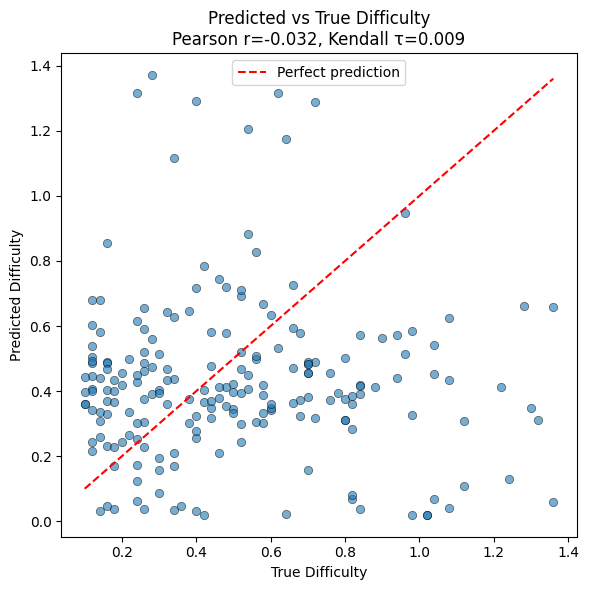

In [41]:
from scipy.stats import pearsonr, kendalltau
from sklearn.metrics import mean_squared_error

true_labels = labels_test.numpy().reshape(-1, 1)
true_labels = scaler_difficulty.inverse_transform(true_labels).flatten()

mse  = mean_squared_error(true_labels, predictions)
rmse = np.sqrt(mse)
pearson_r, pearson_p = pearsonr(true_labels, predictions)
kendall_tau, kendall_p = kendalltau(true_labels, predictions)

print("=== Test Set Evaluation ===")
print(f"  MSE              : {mse:.4f}")
print(f"  RMSE             : {rmse:.4f}")
print(f"  Pearson r        : {pearson_r:.4f}  (p={pearson_p:.4e})")
print(f"  Kendall tau      : {kendall_tau:.4f}  (p={kendall_p:.4e})")

plt.figure(figsize=(6, 6))
plt.scatter(true_labels, predictions, alpha=0.6, edgecolors='k', linewidths=0.5)
plt.plot([true_labels.min(), true_labels.max()], [true_labels.min(), true_labels.max()], 'r--', label='Perfect prediction')
plt.xlabel('True Difficulty')
plt.ylabel('Predicted Difficulty')
plt.title(f'Predicted vs True Difficulty\nPearson r={pearson_r:.3f}, Kendall τ={kendall_tau:.3f}')
plt.legend()
plt.tight_layout()
plt.show()
